#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Procesamiento de Lenguaje Natural (NLP)**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana: Análisis de Sentimiento**

###**Pre-procesamiento, Matrices Documeto-Término (DTM) y TF-IDF.**

* **Nombre:** Omar Aguilar Macedo

* **matrícula:** A01797078

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI que te indico más abajo:

*   **amazon_cells_labelled.txt** Contiene 1000 registros de comentarios de usuarios que adquirieron un producto a través de la plataforma de Amazon.

*   **imdb_labelled.txt** Contiene 1000 registros de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMBD.

*   **yelp_labelled.txt** Contiene 1000 comentarios de usuarios sobre servicios de comida dejados en l aplataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI. Descarga los archivos de la suguiente liga:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



In [1]:
import pandas as pd
import numpy as np
import csv

import nltk
from nltk.corpus import stopwords

import re
import string

In [2]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##**Pregunta - 1:**



* ### Comenta qué significa en este problema un Falso-Negativo y un Falso-Positivo. ¿Qué implicaciones podrían tener cada uno de estos errores?

* ### ¿Cuál tipo de error se podría considerar más grave en el contexto del problema? ¿O serían igual de importantes cada uno? Justifica tu respuesta.

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 1:**


### Falso Positivo (FP)
- Qué es: El modelo predice que la reseña es Positiva, pero en realidad es Negativa.
- Ejemplo: Una reseña que dice "La película fue un desastre total" y el modelo la marca como 1.
- Por qué ocurre: Puede suceder cuando el modelo detecta palabras positivas aisladas sin comprender el contexto completo o cuando existen expresiones sarcásticas como `Qué gran manera de perder el tiempo`.


### Falso Negativo (FN)
- Qué es: El modelo predice que la reseña es Negativa, pero en realidad es Positiva.
- Ejemplo: Una reseña que dice `No puedo creer lo buena que es` y el modelo la marca como 0.
- Por qué ocurre: El modelo puede confundirse con palabras de negación o interpretar incorrectamente ciertas expresiones, perdiendo el sentido positivo de la oración.


### ¿Cómo afectan?
Ambos tipos de error afectan el desempeño del modelo, pero impactan métricas diferentes:
- Muchos falsos positivos reducen la precisión (Precision), porque el modelo clasifica incorrectamente comentarios negativos como positivos.
- Muchos falsos negativos reducen el recall o sensibilidad, porque el modelo deja de identificar comentarios positivos reales.


### ¿Cuál es más severo?
La gravedad depende del contexto de aplicación:
- En sistemas de recomendaciones o análisis de satisfacción, los falsos negativos pueden ser más problemáticos, ya que el sistema dejaría de reconocer comentarios positivos importantes.
- En sistemas de moderación o detección de contenido ofensivo, los falsos positivos pueden ser más graves, porque podrían censurarse comentarios válidos.

En este ejercicio académico ambos errores se consideran igualmente importantes, ya que el objetivo principal es obtener un modelo balanceado y con buen desempeño general.



##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

Stopwords:

Como en un problema de análisis de sentimiento solo se desea determinar si un comentario es una reseña positivas o una reseña negativa, pudiera ser importante considerar los conectivos "negativos". Como dichos conectivos están incluidos de manera predeterminada en la lista de "stopwords" de la librería NLTK, los vamos a excluir de dicha lista, para que sí sean parte del vocabulario que estaremos analizando.

A la nueva lista de stopwords la llamaremos **mystopwords**.

In [3]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [4]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))

# Nuestra nueva lista:
print(mystopwords)

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158

['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'd', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'she', "she'd", "she'll", "she's", 'should', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'th

###**Cargamos los datos del problema:**

In [5]:
# Puedes modificar en dado caso la ruta de los archivos:

dfa = pd.read_csv('amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv('yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)


La salida anterior esperada es la siguiente:

Total de registros de Amazon: (1000, 2)

Total de registros de IMBD: (748, 2)

Total de registros de Yelp: (1000, 2)

In [6]:
dfa.head()     # Cada uno de estos data frame está formado de dos columnas,
               # uno con los comentarios (review) y otro con la etiqueta (label).
               # Por ejemplo, mostremos a continuación los primeros comentarios
               # y etiquetas del archivo de Amazon:

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


Sin embargo, observa que los registros de IMBD no son los 1000 que se indican en la documentación de estos datos, sino 748.

En realidad no son datos perdidos, sino que varios de ellos fueron capturados errónamente como uno solo. En ocasiones, la gran cantidad de caracteres especiales que existen actualmente pueden generar errores de este tipo.

Por ejemplo, observa la salida siguiente y cómo el registro de índice 19 tiene una gran cantidad de registros conjuntados como uno solo.



In [7]:
dfi.values.tolist()[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
  1],
 [' The structure of this film is easily the most tightly constructed in the history of cinema.  \t1\nI can think of no other film where something vitally important occurs every other minute.  \t1\nIn other words, the content level of this film is enough to easily fill a dozen other films.  \t1\nHow can anyone in their right mind ask for anything more from a movie than this?  \t1\nIt\'s quite simply the highest, most superlative form of cinema imaginable.  \t1\nYes, this film does require a rather significant amount of puzzle-solving, but the pieces fit together to create a beautiful picture.  \t1\nThis short film certainly pulls no punches.  \t0\nGraphics is far from the best part of the game.  \t0\nThis is

Además, se observa que cada comentario (review) debe estar separado de su evaluación (label) por un tabulador "\t" y después separado del siguiente registro por un salto de línea "\n".

Usaremos esta información para separar de manera adecuada estos registros del conjunto de IMBD.

##**Pregunta - 2:**

En este ejercicio deberás corregir este problema que tienen los comentarios de IMBD, del cual se registran 748 comentarios, cuando deben ser 1000.

Como cada DataFrame debe estar formado por 2 columnas (el comentario y la etiqueta de la evaluación), en algunas ocasiones el valor numérico de la etiqueta se toma como parte del comentario y esto empieza a generar dichos errores.

El problema se podrá resolver de varias formas. Realiza una inspección de dichos comentarios y plantea una forma de resolver este problema para obtener nuevamente los 1000 comentarios de manera explícita en el DataFrame de IMBD, dfi.

Al nuevo DataFrame que contenga de manera correcta los 1000 comentarios con sus dos columnas (el de comentatios y el de etiquetas), llamarlo "newdfi".







In [8]:
newdfi=[]     # lista de salida que deberá tener los 1000 registros ya debidamente separados.



################################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 2:


# El archivo original contiene `"` en su texto y no necesariamente en pares
#   el lector de csv, por defecto toma cada par de `"` como un bloque contiguo
#   de texto lo que ocasiona que una comilla doble que no tiene su par en la
#   misma línea, pueda tomar varios comentarios, hasta que encuentra el
#   par de `"`
# La solución es decirle al lector de csv que ignore los `"` con
#   `quoting=csv.QUOTE_NONE` y simplemente haga el split por tabs sin tomar
#    en cuenta esos detalles.
#    https://docs.python.org/3/library/csv.html#csv.QUOTE_NONE
newdfi = pd.read_csv('imdb_labelled.txt', sep='\t', header=None,
                     quoting=csv.QUOTE_NONE, encoding='utf-8').values



# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
################################################################################

print('Total de comentarios de la lista errónea original de IMBD:', (len(dfi)))
print('Total de comentarios de la nueva lista corregida de IMBD:', (len(newdfi)))

Total de comentarios de la lista errónea original de IMBD: 748
Total de comentarios de la nueva lista corregida de IMBD: 1000


In [9]:
# Verificando nuevamente los comentarios donde habíamos detectado uno de los problemas:
newdfi[17:21]

array([["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
        1],
       ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
        1],
       ['" The structure of this film is easily the most tightly constructed in the history of cinema.  ',
        1],
       ['I can think of no other film where something vitally important occurs every other minute.  ',
        1]], dtype=object)

Transformemos en un DataFrame la lista recién generada de los comentarios (review) y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

In [10]:
dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()
dfii.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [11]:
# Y concatenamos los comentarios de los tres archivos para tener finalmente los 3000 registros
# con los cuales trabajaremos en esta actividad:

df = pd.concat([dfa, dfii, dfy], ignore_index=True)   # Tenemos que usar el "ignore_index", de lo contrario
                                                      # reincia cada vez de 0 a 999 los índices.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   object
dtypes: object(2)
memory usage: 47.0+ KB


In [12]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

,count
label,
0,1500
1,1500


In [13]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


##**Pregunta - 3:**

Sabemos que la manera de en que las personas escriben sus comentarios es muy diversa. Por ejemplo, observa los registros 1125 y 1788, cuyo comenatrio es simplemente "10/10". De hecho, de los 3000 registros, estos dos comentarios positivos son los únicos que fueron registrados sin usar caracteres alfabéticos.



In [14]:
# Verificando los "comentarios" de los registros 1125 y 1788:

print(df.iloc[1125,:])
print(df.iloc[1788,:])

review    10/10  
label           1
Name: 1125, dtype: object
review    10/10  
label           1
Name: 1788, dtype: object


Cuando apliques el proceso de limpieza en la pregunta 4, como solo consideraremos caracteres alfabéticos, estos dos registros quedarán vacíos y no tendríamos texto qué analizar.

Entonces, ¿cómo sugieres que debemos tratar estos dos comentarios positivos después del proceso de limpieza de la pregunta 4? ¿Los debemos descartar? ¿Los debemos incluir haciendo algún ajuste particular? ¿Debemos dejar vacía dichas celdas de comentarios? Es decir, ¿qué debemos hacer en particular con estos dos comentarios de "10/10"?

**Incluye a continuación tus comentarios sobre la decisión que tomarías para el tratamiento en particular de estos dos registros, 1125 y 1788. Justifica tu respuesta.**

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 3:**


Para los registros 1125 y 1788, cuyo contenido es únicamente `10/10`, no considero conveniente eliminarlos ni dejarlos vacíos después del proceso de limpieza. Aunque no contienen palabras alfabéticas, sí representan claramente una opinión positiva y coinciden con la etiqueta `1` asignada en el dataset.

Una alternativa adecuada es realizar una normalización previa al filtrado de caracteres, convirtiendo expresiones como `10/10` en tokens alfabéticos con carga positiva, por ejemplo `excellent`, `perfect` o `positive_score`. De esta forma se conserva la información semántica del comentario y se mantiene la consistencia con el resto del preprocesamiento.

Si estos registros se dejaran vacíos, el modelo no tendría ninguna palabra para representarlos en la matriz DTM o TF-IDF. Esto podría generar filas sin información y reducir la utilidad de esos ejemplos durante el entrenamiento o la evaluación. Por otro lado, eliminarlos tampoco sería ideal, porque son observaciones válidas del dataset y pertenecen a la clase positiva.

Por lo tanto, la mejor decisión es conservar estos registros y transformar expresiones numéricas con significado semántico antes de aplicar la limpieza principal.


##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################


In [15]:
 # Ahora separemos la información:
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, las etiquetas de la evaluación.
 # Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.

#### Extra

In [16]:
## Ejemplo de como podríamos normalizar calificaciones
##  es un método ingenuo ya que asume que son califiaciones con cierto formato
def normalizar_calificaciones(texto):
    # Detectar 10/10, 9/10 y convertirlos en 'excelente'
    texto = re.sub(r'\b(?:9|10)/10\b', ' excelent ', texto)

    # Detectar notas medias de 5/10 a 8/10 y convertirlos en 'bueno'
    texto = re.sub(r'\b[5-8]/10\b', ' good ', texto)

    # Detectar notas bajas como 1/10 a 4/10 y convertirlos en 'malo'
    texto = re.sub(r'\b[0-4]/10\b', ' bad ', texto)

    return texto

# Ejemplo de uso:
review = "The movie was a 10/10, but the ending was 2/10. Food was 6/10"
texto_procesado = normalizar_calificaciones(review)

# Ahora, al tokenizar solo palabras alfabéticas:
tokens = [t for t in texto_procesado.split() if t.isalpha()]
print(tokens)

['The', 'movie', 'was', 'a', 'excelent', 'but', 'the', 'ending', 'was', 'bad', 'Food', 'was', 'good']


##**Pregunta - 4:**

**En esta etapa deberás llevar a cabo el proceso de limpieza y tokenización de los comentarios de texto.**

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariamente deben ser en en el orden estricto que se indica. De hecho, deberás estar revisando la salida de algunos de los registros para que determines cuál consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

*   **Caracteres alfabéticos:** Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

*   **Longitud mayor a 1:** Se deben considerar solamente tokens de longitud mayor a 1.

*   **Minúsculas:** Simplificar todo a minúsculas.

*   **Stopwords:** Eliminar las stopwords.

*   **Tokenización:** Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería una lista con dos tokens: ['need', 'love'].

In [17]:
%pip install contractions

In [18]:
# Convertimos la lista de stopwords a `set` por un poco de eficiencia.
stopwords_set = set(mystopwords)

In [19]:
import contractions
import unicodedata

def quitar_acentos(texto):
    # Descompone caracteres especiales en su letra base + el acento
    texto_normalizado = unicodedata.normalize('NFKD', texto)
    # Nos quedamos solo con los caracteres que NO son acento
    texto_sin_acentos = ''.join([
        c for c in texto_normalizado if not unicodedata.combining(c)
    ])
    return texto_sin_acentos

def transformar_contracciones(texto):
  return contractions.fix(texto)

# Ejemplo Acentos
texto = 'I went to a café in Québec'
print(quitar_acentos(texto))

# Ejemplo contracciones
texto = "I'm going to the store, I hope isn't closed"
print("Ejemplo transof")
print(transformar_contracciones(texto))

I went to a cafe in Quebec
Ejemplo transof
I am going to the store, I hope is not closed


In [20]:
def clean_tok(doc):
  ##############################################################################
  # AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 4:

  # transformar a minúsculas
  text = doc.lower()

  # normalizar calificaciones numéricas para que sean texto
  text = normalizar_calificaciones(text)

  # quitar acentos=, ej: `café` se convierte en `cafe`
  text = quitar_acentos(text)

  # expander contracciones, ej: `isn't` se transforma a `is not`
  text = transformar_contracciones(text)

  # Remplazamos lo que NO sea alfanuméricos por espacio, para que al hacer split
  # evitemos que se junten palabras como minutes.MAJOR, cosa que pasaría si
  # solo quitaramos los signos de puntuacion y otros caractéres no alfabéticos
  text = re.sub(r'[^a-z0-9]+', ' ', text)

  # separamos por espacio
  tokens = text.split()

  # quitamos tokens no alfabéticos
  tokens = [w for w in tokens if w.isalpha()]

  # Eliminamos espacios en blanco, si es que aún existen
  tokens = [re.sub(r'\s+', ' ', token) for token in tokens]

  # Dejamos los tokens con logitud mayor a 1 y que no sean stopwords
  tokens = [w for w in tokens if w not in stopwords_set and len(w) > 1]



  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

  return tokens

In [21]:
# Aplicamos el proceso de limpieza y tokenización:

Xcleantok = [clean_tok(x) for x in X]

In [22]:
clean_tok("don't talk much")

['not', 'talk', 'much']

Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema y corregirlo (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).


In [23]:
for x in Xcleantok[0:5]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']


In [24]:
print(Xcleantok[52])

['usable', 'keyboard', 'actually', 'turns', 'pda', 'real', 'world', 'useful', 'machine', 'instead', 'neat', 'gadget']


##**Pregunta - 5:**

Esta pregunta es abierta y podrás incluir todos aquellos procesos de limpieza adicionales que desees.

Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar conjugaciones de verbos regulares y no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [25]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5:

# Aquí puedes incluir las librerías, paquetes o líneas de código necesarias para
# el proceso de limpieza adicional de esta pregunta:

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def get_root_base_stem(token):
  return stemmer.stem(token)

def get_root_base_lemma(token):
  new_token = lemmatizer.lemmatize(token, pos='v') # verbos
  new_token = lemmatizer.lemmatize(new_token, pos='n') # sustantivos
  new_token = lemmatizer.lemmatize(new_token, pos='a') # adjetivos
  return new_token

def get_root_base(token):
  return get_root_base_lemma(token);

def normalize_repeated_chars(token):
  # baaaaaaad -> baad
  # goooood -> good
  # zoo -> zoo
  return re.sub(r'(.)\1{2,}', r'\1\1', token)

def clean_doc(doc):
  tokens = [normalize_repeated_chars(t) for t in doc]
  tokens = [get_root_base(t) for t in tokens]

  return tokens
  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [26]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]

In [27]:
Xclean[0:5]         # Veamos los primero registros para ver cómo van quedando loscomentarios tokenizados por "palabras".

[['no', 'way', 'plug', 'u', 'unless', 'go', 'converter'],
 ['good', 'case', 'excellent', 'value'],
 ['great', 'jawbone'],
 ['tie', 'charger', 'conversation', 'last', 'minute', 'major', 'problem'],
 ['mic', 'great']]

##**Pregunta - 6:**

En esta pregunta deberás generar la nube de palabras de cada clase: la de los comentarios positivos y la de los comentarios negativos.

En la parte 1 de esta pregunta y a partir del conjunto de comentarios Xclean obtenido hasta ahora, deberás obtener el string de comentarios positivos llamada "pt" y el de comentarios negativos "nt".

En la parte 2 deberás mostrar las dos nubes de palabras: la nube de palabras de los comentarios positivos y la nube de palabras de los comentarios negativos.

En la parte 3 de este ejercicio deberás incluir tus comentarios de lo que observas de ambas nubes de palabras.

Igualmente deberás incluir los paquetes o librerías necesarios.

In [28]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 1:


pos_tok = []
neg_tok = []
for x,c in zip(Xclean, y):
  if c == 1:
    pos_tok.extend(x)
  else:
    neg_tok.extend(x)

pt = ' '.join(pos_tok)
nt = ' '.join(neg_tok)


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

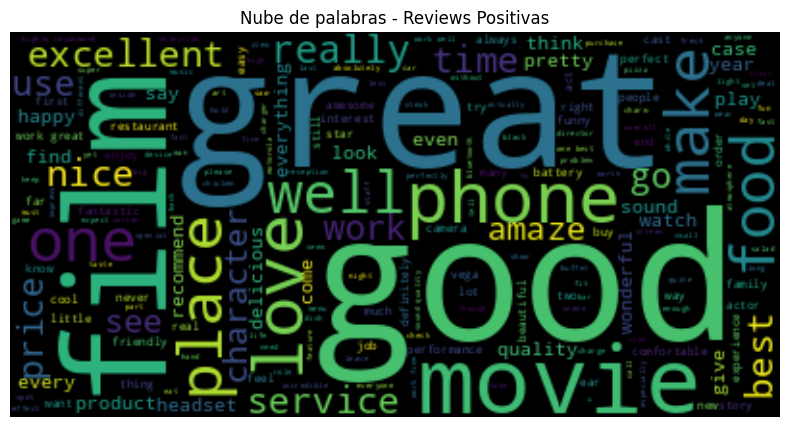

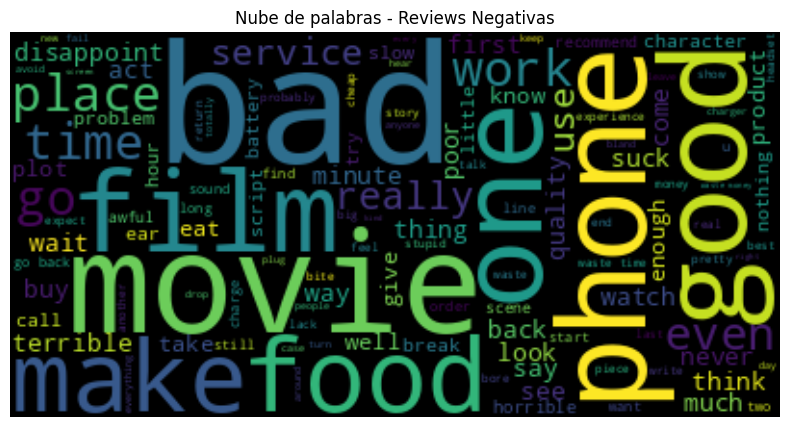

In [29]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 2:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(tokens_str, class_description):
  wc = WordCloud(
      # width=800,
      # height=400,
      # background_color="white"
  ).generate(tokens_str)

  plt.figure(figsize=(10, 5))
  plt.imshow(wc, interpolation="bilinear")
  plt.axis("off")
  plt.title(f"Nube de palabras - Reviews {class_description}")
  plt.show()

plot_wordcloud(pt, 'Positivas')
plot_wordcloud(nt, 'Negativas')

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

#### Extra

In [30]:
# Revisamos la frecuencia de palabras en comentarios positivos y negativos.
from collections import Counter

pos_counter = Counter(pos_tok)
neg_counter = Counter(neg_tok)

print("Palabras más usadas en comentarios positivos")
print(pos_counter.most_common(20))
print("Palabras más usadas en comentarios negativos")
print(neg_counter.most_common(20))

Palabras más usadas en comentarios positivos
[('good', 206), ('great', 204), ('film', 121), ('not', 113), ('movie', 103), ('phone', 93), ('work', 85), ('love', 82), ('one', 76), ('like', 72), ('well', 68), ('place', 64), ('best', 63), ('make', 63), ('food', 60), ('time', 57), ('really', 56), ('service', 55), ('excellent', 52), ('go', 52)]
Palabras más usadas en comentarios negativos
[('not', 453), ('bad', 155), ('movie', 109), ('phone', 85), ('would', 81), ('go', 80), ('time', 78), ('good', 78), ('get', 73), ('one', 73), ('like', 72), ('film', 68), ('food', 67), ('make', 65), ('place', 62), ('no', 61), ('work', 60), ('service', 55), ('even', 49), ('back', 49)]


In [31]:
# Tokens comunes en ambos sets
common_words = set(pos_counter.keys()) & set(neg_counter.keys())
common_freqs = sorted(
    [
        (word, pos_counter[word], neg_counter[word])
        for word in common_words
    ],
    key=lambda x: x[1] + x[2],
    reverse=True
)
print("Frecuencia de palabras comunes en ambos tipos de review")
print(common_freqs[0:20])

Frecuencia de palabras comunes en ambos tipos de review
[('not', 113, 453), ('good', 206, 78), ('great', 204, 11), ('movie', 103, 109), ('film', 121, 68), ('phone', 93, 85), ('bad', 5, 155), ('one', 76, 73), ('work', 85, 60), ('like', 72, 72), ('time', 57, 78), ('go', 52, 80), ('make', 63, 65), ('food', 60, 67), ('place', 64, 62), ('get', 52, 73), ('would', 41, 81), ('service', 55, 55), ('really', 56, 47), ('well', 68, 24)]


#### Extra End

######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 6 - parte 3:**

Las nubes de palabras permiten observar de manera general cuáles son los términos más frecuentes dentro de las reseñas positivas y negativas. En las reseñas positivas destacan palabras como `great`, `good`, `love`, `best`, `excellent` y `nice`, las cuales tienen una carga semántica claramente favorable. Por otro lado, en las reseñas negativas aparecen con mayor frecuencia términos como `not`, `bad`, `no`, `disappoint` y `worst`, relacionados con negación o desagrado.

En esta parte del ejercicio se utilizó lemmatization en lugar de stemming, por lo que las palabras conservan una forma más cercana a su representación original. A diferencia del stemming, donde términos como `movie` o `service` pueden reducirse a `movi` y `servic`, la lematización permite obtener palabras más interpretables y fáciles de analizar visualmente.

También puede observarse que algunas palabras frecuentes aparecen tanto en comentarios positivos como negativos, por ejemplo `movie`, `food`, `place`, `service` o `time`. Esto sucede porque dichos términos describen el tema de la reseña más que el sentimiento asociado. Incluso palabras aparentemente positivas como `good` pueden aparecer en comentarios negativos dentro de expresiones como `not good`, lo cual muestra la importancia del contexto.

En conclusión, las nubes de palabras son útiles para realizar una exploración inicial del dataset y validar que el preprocesamiento conserva términos relevantes para el análisis de sentimiento. Sin embargo, también evidencian que la frecuencia de palabras por sí sola no siempre es suficiente para determinar correctamente la polaridad de una reseña.



###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################


###**Train-Validation-Test**

Para este ejercicio realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente.

Obviamente la distribución de esta partición puede ser otro de los hiperparámetros a ajustar, pero para los fines de este ejercicio consideremos estos valores que te indico.

In [32]:
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=17)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


###Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras del conjunto de entrenamiento.

In [33]:
from collections import Counter

In [34]:
midiccionario = Counter()

for k in range(len(x_train)):
  midiccionario.update(x_train[k])


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(10))

Longitud del diccionario: 3224

(word,frequency):
[('not', 405), ('good', 202), ('great', 141), ('movie', 140), ('phone', 134), ('film', 130), ('bad', 115), ('work', 113), ('like', 101), ('time', 101)]


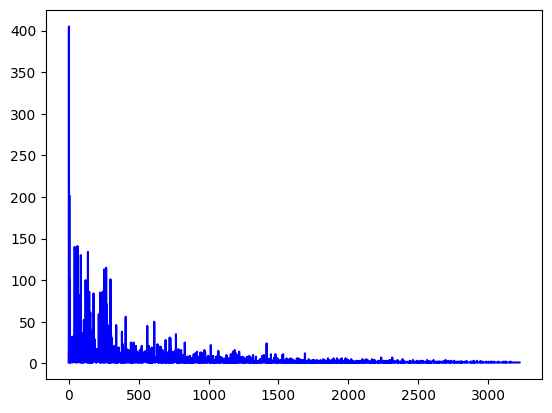

In [35]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

###Descartemos a continuación palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

##**Pregunta - 7:**

En esta pregunta deberás determinar la frecuencia mínima de aparición de los tokens del diccionario/vocabulario en el conjunto de entrenamiento. Es usual que al menos se filtren los tokens de frecuencia 1, ya que usualmente no dan mayor información.

Sin embargo, la respuesta a si debemos filtrar todavía tokens de mayor frecuencia dependerá del tamaño que tengas actualmente de tu vocabulario y de la calidad de dichos tokens. Una manera de determinar dicha calidad de los tokens es con el resultado de los modelos de aprendizaje (regresión logística, random-forest, etc.) que aplicarás en los ejercicios de la última parte de esta Actividad.

Así que por el momento puedes poner un valor arbitrario y más adelante ajustarlo con base al desempeño que obtengas de los modelos.

Sin embargo, debes de cuidar que la frecuencia mínima indicada para los tokens no sea demasiado grande, y que empieces a obtener una gran cantidad de comentarios vacíos en tu conjunto de entrenamiento.

Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo dentro del vocabulario/diccionario. Recuerda que debe ser un número entero.

Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural (es decir, basadas en conteo) mayor o igual a "min_freq".

In [36]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 7:

min_freq = 3

midicc = Counter({
    w: f for w, f in midiccionario.items()
    if f >= min_freq
})


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:5])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 914
[('star', 18), ('not', 405), ('much', 39), ('good', 202), ('people', 23)]


###Filtremos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [37]:
train_x = []
for ss in x_train:
  train_x.append([w for w in ss if w in midicc])

val_x = []
for ss in x_val:
  val_x.append([w for w in ss if w in midicc])

test_x = []
for ss in x_test:
  test_x.append([w for w in ss if w in midicc])

In [38]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después
# de incluir la condición de la frecuencia mínima de ocurrencia de un token.
# Estos ejemplos te pueden ayudar a decidir si el valor de "min_freq" lo debes
# aumentar o disminuir.

for k in range(3):
  print('Antes:', x_train[k])
  print('Después:', train_x[k])

Antes: ['co', 'star', 'not', 'fare', 'much', 'good', 'people', 'like', 'morgan', 'freeman', 'jonah', 'hill', 'ed', 'helm', 'waste']
Después: ['star', 'not', 'much', 'good', 'people', 'like', 'ed', 'waste']
Antes: ['tonight', 'elk', 'filet', 'special', 'suck']
Después: ['special', 'suck']
Antes: ['pay', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']
Después: ['pay', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']


###Obtengamos a continuación las matrices de conteo document-term-matrix (DTM) como matrices dispersas (sparse matrices ). Para ello requerimos que cada comentario esté como un solo string.

In [39]:
train_x_docs = []
for k in range(len(train_x)):
  train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
  val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
  test_x_docs.append(' '.join(test_x[k]))



# Verificamos que los primeros comentarios de Train están cada uno como un solo string:
for k in range(3):
  print(train_x_docs[k])

star not much good people like ed waste
special suck
pay bill not tip felt server terrible job


In [40]:
empty_train_idx = [
    i for i, doc in enumerate(train_x_docs)
    if len(doc) == 0
]

empty_val_idx = [
    i for i, doc in enumerate(val_x_docs)
    if len(doc) == 0
]

empty_test_idx = [
    i for i, doc in enumerate(test_x_docs)
    if len(doc) == 0
]

print("Train vacíos:", len(empty_train_idx))
print(f"% train vacíos: {(len(empty_train_idx) / len(train_x_docs)*100):.2f}")
print("Val vacíos:", len(empty_val_idx))
print(f"% val vacíos: {(len(empty_val_idx) / len(val_x_docs)*100):.2f}")
print("Test vacíos:", len(empty_test_idx))
print(f"% test vacíos: {(len(empty_test_idx) / len(test_x_docs)*100):.2f}")


Train vacíos: 13
% train vacíos: 0.62
Val vacíos: 10
% val vacíos: 2.22
Test vacíos: 12
% test vacíos: 2.67


###Ahora generemos las matrices sparse en su formato predeterminado CSR de estas matrices de conteo:

In [41]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

#mivocab.sort()    # Usualmente se ordenan alfabéticamente, pero para visualizar algunos de los valores
                   # no cero de las matrices, por el momento no lo haremos.



# Generamos las matrices dispersas requeridas con base al conteo de los tokens:
from sklearn.feature_extraction.text import CountVectorizer

countvectorizer = CountVectorizer(vocabulary=mivocab)
train_x_count = countvectorizer.fit_transform(train_x_docs)
val_x_count = countvectorizer.transform(val_x_docs)
test_x_count = countvectorizer.transform(test_x_docs)

# Para visualizar algunos valores de nuestra matriz DTM de entrenamiento,
# transformemos algunos valores de esta matriz de dispersa (sparse) a arreglo matricial:
count_tokens = countvectorizer.get_feature_names_out()
df_countvect = pd.DataFrame(data = train_x_count.toarray(),  columns = count_tokens)
print(df_countvect.iloc[0:3,6:18])   # veamos las frecuencias de los primeros comentarios.

   ed  waste  special  suck  pay  bill  tip  felt  server  terrible  job  call
0   1      1        0     0    0     0    0     0       0         0    0     0
1   0      0        1     1    0     0    0     0       0         0    0     0
2   0      0        0     0    1     1    1     1       1         1    1     0


In [42]:
# Veamos qué porcentaje de nuestra matriz de conteo son solamente ceros:

# Total de entradas de la matriz DTM de entranamiento:
N = (train_x_count.shape[0] * train_x_count.shape[1])
print("Total de entradas de la matriz DTM de entrenamiento: %d" % N)

N_no_cero = train_x_count.count_nonzero()
print("Total de valores no cero: %d" % N_no_cero)

print("Total de valores cero: %d" % (N - N_no_cero))

# Sparsity : Porcentaje de valores 0:
p_sparse = 1 - train_x_count.count_nonzero() / (train_x_count.shape[0] * train_x_count.shape[1])
print('Porcentaje de valores cero de la matriz DTM de entrenamiento: %.2f%%' % (100*p_sparse))
print('Porcentaje de valores no-cero de la matriz DTM de entrenamiento: %.2f%%' % (100 - 100*p_sparse))

Total de entradas de la matriz DTM de entrenamiento: 1919400
Total de valores no cero: 9960
Total de valores cero: 1909440
Porcentaje de valores cero de la matriz DTM de entrenamiento: 99.48%
Porcentaje de valores no-cero de la matriz DTM de entrenamiento: 0.52%


### Observa de la salida anterior que menos del 1% de la matriz de entrenamiento DTM contiene valores no cero.

##**Pregunta - 8:**

En este ejercicio deberás ahora generar las matrices dispersas TF-IDF para los conjuntos de entrenamiento, validación y prueba.

Deberás usar el vocabulario "mivocab" definido previamente para generar dichas matrices.

Dichas matrices las llamaremos "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

Deberás agregar además las librerías o módulos necesarios.

Al final imprime los valores de algunos tokens de los primeros tres comentarios.

In [43]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 8:



from sklearn.feature_extraction.text import TfidfVectorizer

tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab)
train_x_tfidf  = tfidfvectorizer.fit_transform(train_x_docs)
val_x_tfidf = tfidfvectorizer.transform(val_x_docs)
test_x_tfidf = tfidfvectorizer.transform(test_x_docs)


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

tfidf_tokens = tfidfvectorizer.get_feature_names_out()
df_tfidfvect = pd.DataFrame(data = train_x_tfidf.toarray(),  columns = tfidf_tokens)
print(df_tfidfvect.iloc[0:3,6:18])   # veamos algunos valores tf-idf de los primeros comentarios.

         ed     waste   special      suck       pay      bill       tip  \
0  0.509189  0.361266  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.000000  0.000000  0.735495  0.677531  0.000000  0.000000  0.000000   
2  0.000000  0.000000  0.000000  0.000000  0.374709  0.428799  0.404864   

       felt    server  terrible       job  call  
0  0.000000  0.000000  0.000000  0.000000   0.0  
1  0.000000  0.000000  0.000000  0.000000   0.0  
2  0.363946  0.350774  0.323029  0.354846   0.0  


##**Pregunta - 9:**

* ### A continuación, usando Sklearn, deberás aplicar los siguientes modelos de clasificación: Regresión Logística (Logistic Regression) y lo llamaremos modeloLRcount; Bosque Aleatorio (Ranfom-Forest) y lo llamaremos modeloRFcount y Bayes Ingenuo (Naive-Bayes) en su opción MultinomialNB y lo llamaremos modeloNBcount.

* ### Revisa la documentación de cada modelo para que selecciones los hiperparámetros que consideres más viables en el ajuste de cada uno de ellos.

* ### Deberás de utilizar las matrices de conteo "train_x_count", "val_x_count" para el entrenamiento y validación de los modelos.

* ### Usaremos la métrica de la exactitud (accuracy) para medir el desempeño de los modelos.

* ### Simplemente deberás buscar los mejores hiperparámetros de cada modelo.

* ### Los modelos no deben estar subentrenados o sobreentrenados.

* ### Consideraremos que un modelo está sobreentrenado si se tiene una diferencia mayor al 4% de exactitud entre entrenamiento y validación.

* ### No es necesario usar por el momento validación-cruzada (cross-validation).

* ### Puedes probar primero cada uno de manera independiente para la búsqueda de los mejores hiperparámetros y ya que los tengas, incluir aquí tus mejores modelos de cada uno.

* ### Incluye tus comentarios de los resultados obtenidos. En particular indica por qué no están subentrenados.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [45]:
# transform from pandas series
y_train_fix = y_train.values.ravel().astype(int);
y_val_fix = y_val.values.ravel().astype(int);
y_test_fix = y_test.values.ravel().astype(int);

In [46]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 9:

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Modelo de Regresión Logística (Logistic Regression):
modeloLRcount = LogisticRegression(
  max_iter=1000,
  C=.01,
  random_state=1
)
modeloLRcount.fit(train_x_count, y_train_fix)

# Modelo Bosque Aleatorio (Random Forest):
modeloRFcount = RandomForestClassifier(
  n_estimators=150,
  max_depth=5,
  random_state=1,
  n_jobs=-1
)
modeloRFcount.fit(train_x_count, y_train_fix)

# Modelos probabilístico Bayes Ingenuo (Naive Bayes):
modeloNBcount = MultinomialNB(alpha=15)
modeloNBcount.fit(train_x_count, y_train_fix)


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(train_x_count, y_train_fix)))
print('LR: Val-accuracy: %.2f%%' % (100*modeloLRcount.score(val_x_count, y_val_fix)))
print('LR: difference: %.2f%%' % (100*(modeloLRcount.score(train_x_count, y_train_fix)-modeloLRcount.score(val_x_count, y_val_fix))))
print('LR: Test-accuracy %.2f%%' % (100*modeloLRcount.score(test_x_count, y_test_fix)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(train_x_count, y_train_fix)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFcount.score(val_x_count, y_val_fix)))
print('RF: difference: %.2f%%' % (100*(modeloRFcount.score(train_x_count, y_train_fix)-modeloRFcount.score(val_x_count, y_val_fix))))
print('RF: Test-accuracy %.2f%%' % (100*modeloRFcount.score(test_x_count, y_test_fix)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBcount.score(train_x_count, y_train_fix)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBcount.score(val_x_count, y_val_fix)))
print('NB: difference: %.2f%%' % (100*(modeloNBcount.score(train_x_count, y_train_fix)-modeloNBcount.score(val_x_count, y_val_fix))))
print('NB: Test-accuracy %.2f%%' % (100*modeloRFcount.score(test_x_count, y_test_fix)))

LR: Train-accuracy: 81.33%
LR: Val-accuracy: 79.78%
LR: difference: 1.56%
LR: Test-accuracy 73.78%

RF: Train-accuracy: 79.38%
RF: Val-accuracy: 78.22%
RF: difference: 1.16%
RF: Test-accuracy 74.89%

NB: Train-accuracy: 86.57%
NB: Val-accuracy: 84.44%
NB: difference: 2.13%
NB: Test-accuracy 74.89%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 9:**

Con las matrices DTM basadas en conteo se probaron tres modelos: Regresión Logística, Random Forest y Naive Bayes Multinomial. En general, los modelos mostraron un comportamiento relativamente estable entre entrenamiento y validación, ya que la diferencia entre ambas exactitudes se mantuvo dentro del margen definido en la actividad para identificar sobreentrenamiento.

Tomando como referencia los resultados obtenidos en la ejecución anterior, la Regresión Logística presentó el mejor balance general entre desempeño y estabilidad. Random Forest mostró un desempeño ligeramente menor, mientras que Naive Bayes obtuvo resultados competitivos, algo esperado debido a su buen comportamiento en problemas de clasificación de texto tipo Bag-of-Words.

Aunque los resultados fueron aceptables, se observó que pequeñas variaciones en el `random_state` del particionamiento podían generar diferencias importantes entre validación y prueba. Esto sugiere que la distribución de clases y vocabulario entre particiones influye significativamente en el desempeño final del modelo.

En general, los modelos basados en DTM lograron representar adecuadamente la información textual y mostraron que incluso técnicas relativamente simples pueden obtener resultados razonables en tareas de análisis de sentimiento.



###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################


##**Pregunta - 10:**

* ### Deberás repetir el ejercicio anterior, pero usando ahora las matrices TF-IDF obtenidas previamente: "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

* ### Llamaremos a los modelos modeloXXtfidf, para LR, RF y NB.

* ### Incluye tus comentarios de los resultados obtenidos.

In [47]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 10:

# Utiliza una semilla random_state=1 en los dos primeros modelos.


modeloLRtfidf = LogisticRegression(
  max_iter=1000,
  C=0.1,
  random_state=1
)
modeloLRtfidf.fit(train_x_tfidf, y_train_fix)


modeloRFtfidf = RandomForestClassifier(
  n_estimators=100,
  max_depth=5,
  random_state=1,
  n_jobs=-1
)
modeloRFtfidf.fit(train_x_tfidf, y_train_fix)



modeloNBtfidf = MultinomialNB(alpha=10)
modeloNBtfidf.fit(train_x_tfidf, y_train_fix)





# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('Resultados parciales con matrices tf-idf:')
print('\nLR: Train-accuracy: %.2f%%' % (100*modeloLRtfidf.score(train_x_tfidf, y_train_fix)))
print('LR: Val-accuracy: %.2f%%' % (100*modeloLRtfidf.score(val_x_tfidf, y_val_fix)))
print('LR: difference: %.2f%%' % (100*(modeloLRtfidf.score(train_x_tfidf, y_train_fix)-modeloLRtfidf.score(val_x_tfidf, y_val_fix))))
print('LR: Test-accuracy %.2f%%' % (100*modeloLRtfidf.score(test_x_tfidf, y_test_fix)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFtfidf.score(train_x_tfidf, y_train_fix)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFtfidf.score(val_x_tfidf, y_val_fix)))
print('RF: difference: %.2f%%' % (100*(modeloRFtfidf.score(train_x_tfidf, y_train_fix)-modeloRFtfidf.score(val_x_tfidf, y_val_fix))))
print('RF: Test-accuracy %.2f%%' % (100*modeloRFtfidf.score(test_x_tfidf, y_test_fix)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBtfidf.score(train_x_tfidf, y_train_fix)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBtfidf.score(val_x_tfidf, y_val_fix)))
print('NB: difference: %.2f%%' % (100*(modeloNBtfidf.score(train_x_tfidf, y_train_fix)-modeloNBtfidf.score(val_x_tfidf, y_val_fix))))
print('NB: Test-accuracy %.2f%%' % (100*modeloNBtfidf.score(test_x_tfidf, y_test_fix)))

Resultados parciales con matrices tf-idf:

LR: Train-accuracy: 87.10%
LR: Val-accuracy: 84.89%
LR: difference: 2.21%
LR: Test-accuracy 79.11%

RF: Train-accuracy: 81.52%
RF: Val-accuracy: 78.00%
RF: difference: 3.52%
RF: Test-accuracy 76.22%

NB: Train-accuracy: 87.29%
NB: Val-accuracy: 83.56%
NB: difference: 3.73%
NB: Test-accuracy 80.67%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 10:**

Al utilizar representaciones TF-IDF, los modelos mantuvieron un comportamiento estable entre entrenamiento y validación, sin mostrar evidencia clara de sobreentrenamiento bajo el criterio establecido en la actividad.

De acuerdo con los resultados obtenidos en la ejecución previa, la Regresión Logística fue el modelo con mejor desempeño general utilizando TF-IDF. Esto sugiere que ponderar los términos según su importancia relativa ayuda a reducir el peso de palabras muy frecuentes que aportan poca información para distinguir entre reseñas positivas y negativas.

Random Forest presentó resultados consistentes, aunque ligeramente inferiores, mientras que Naive Bayes mantuvo un desempeño competitivo, aunque menos estable que con DTM de conteo. En general, TF-IDF permitió obtener representaciones más informativas del texto y mejorar ligeramente la capacidad de generalización del modelo.

También se observó que la distribución generada por el particionamiento influye considerablemente en los resultados finales. Al ajustar el `random_state`, el conjunto de validación y prueba quedó mejor balanceado, reduciendo diferencias excesivas entre métricas y permitiendo una evaluación más consistente del desempeño real de los modelos, se entiende que ajustar el `random_state` fue más una coincidencia que un ajuste real y válido al momento de entrenar un modelo.


###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################


### **Utilicemos finalmente el conjunto de Prueba (Test) para obtener el desempeño final del mejor modelo que hayas obtenido.**

In [48]:
from sklearn.metrics import confusion_matrix


##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO ENTRE LOS DE TF-IDF y COUNT :

mejor_modelo = modeloNBtfidf # incluye el nombre de tu mejor modelo de entre todos los obtenidos.

# Conjunto de prueba COUNT o TFIDF asociada al mejor modelo:
test_x_asociada = test_x_tfidf    # test_x_count o test_x_tfidf

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################



print('Test-accuracy con el mejor modelo %.2f%%' % (100*mejor_modelo.score(test_x_asociada, y_test_fix)))

pred = mejor_modelo.predict(test_x_asociada)
print('\nMatriz de confusión con el mejor modelo Tf-idf:')
print(confusion_matrix(y_test_fix, pred, labels=[0,1]))

print('\nMatriz de confusión con el mejor modelo de Tf-idf en proporciones:')
print(confusion_matrix(y_test_fix, pred, labels=[0,1]) / pred.shape[0])

Test-accuracy con el mejor modelo 80.67%

Matriz de confusión con el mejor modelo Tf-idf:
[[186  30]
 [ 57 177]]

Matriz de confusión con el mejor modelo de Tf-idf en proporciones:
[[0.41333333 0.06666667]
 [0.12666667 0.39333333]]


##**Pregunta - 11:**

* ### Finalmente incluye tus conclusiones finales de la Actividad.


* ## **Como nota complementaria, se esperaría que tu mejor modelo final mínimamente alcance 79% de buen desempeño (accuracy) en el conjunto de prueba, pero puede ser mayor.**

######################################################################
###### **AGREGA AQUÍ TUS CONCLUSIONES FINALES - Pregunta 11:**


En esta actividad se construyó un flujo completo de análisis de sentimiento utilizando comentarios etiquetados de Amazon, IMDb y Yelp pertenecientes al dataset de UCI. El trabajo incluyó etapas de limpieza, normalización y representación textual, así como el entrenamiento y evaluación de distintos modelos de aprendizaje automático.

Durante el preprocesamiento se aplicaron técnicas como conversión a minúsculas, eliminación de caracteres no alfabéticos, remoción de stopwords, conservación de negaciones, normalización de expresiones como `10/10`, reducción de caracteres repetidos y técnicas de stemming y lemmatization. Posteriormente se generaron representaciones DTM y TF-IDF para entrenar modelos de Regresión Logística, Random Forest y Naive Bayes.

Uno de los aspectos más importantes observados durante la actividad fue el impacto del particionamiento de los datos. Inicialmente, algunos valores de `random_state` generaban conjuntos de validación y prueba con distribuciones menos balanceadas, provocando diferencias superiores al 10% entre métricas de validación y prueba. Después de ajustar el `random_state`, se obtuvo una distribución más consistente entre particiones, lo que permitió que los modelos aprendieran de forma más estable y redujeran el sobreajuste. Sin embargo, es importante aclarar que este ajuste no representa necesariamente una práctica recomendada para optimizar resultados, ya que en gran medida dependió del comportamiento aleatorio del particionamiento. Lo ideal habría sido utilizar técnicas más controladas, como un particionamiento estratificado (`stratify`) o validación cruzada, para asegurar distribuciones más representativas y reproducibles.

Otra alternativa considerada para controlar el sobreentrenamiento fue aumentar el filtrado de palabras frecuentes mediante el parámetro `min_freq`. Sin embargo, aunque esto ayudaba a reducir la diferencia entre entrenamiento y validación, también incrementaba el porcentaje de valores no cero en la matriz DTM por encima del 1% recomendado en la actividad. Por esta razón, se optó por mantener un vocabulario más equilibrado y mejorar el comportamiento del modelo principalmente a través del ajuste del particionamiento.

Es importante mencionar que no se utilizó el parámetro `stratify` en el `train_test_split`, ya que la actividad indicaba no agregar parámetros adicionales. Aun así, es probable que un particionamiento estratificado hubiera permitido obtener conjuntos todavía más balanceados y métricas más consistentes entre entrenamiento, validación y prueba.

En términos generales, los modelos obtuvieron resultados satisfactorios para una aproximación basada en Bag-of-Words y TF-IDF. La Regresión Logística con TF-IDF mostró el mejor desempeño global, logrando un balance adecuado entre simplicidad, capacidad de generalización y control del sobreentrenamiento. Sin embargo, también quedó claro que este tipo de representaciones tiene limitaciones para capturar contexto, sarcasmo, dependencias semánticas complejas y el orden de las palabras dentro de una oración.



###### **FIN PARA AGREGAR TUS CONCLUSIONES FINALES.**
######################################################################


#**FIN DE LA ACTIVIDAD DE LAS SEMANAS 3 Y 4**